# Regressão — Communities and Crime

Pipeline de regressão supervisionada sobre o dataset **Communities and Crime** (UCI id=183), alvo `ViolentCrimesPerPop`. Modelos: Regressão Linear, Ridge e Lasso.

## Configuração

Importações, constantes e funções auxiliares reutilizadas em múltiplas etapas.

In [1]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset

warnings.filterwarnings('ignore')

TARGET = 'ViolentCrimesPerPop'

In [2]:
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2_score(y_true, y_pred)}


def construir_pipeline(modelo):
    return Pipeline([('scaler', StandardScaler()), ('modelo', modelo)])


def _calc_stats(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = s[(s < lo) | (s > hi)]
    n   = len(out)
    dev = abs(out - s.median()).max() / (iqr if iqr > 0 else 1) if n > 0 else 0.0
    return {'skew': s.skew(), 'n_out': n, 'pct': 100 * n / len(s), 'dev': dev}


def near_zero_var(df, freq_cut=95/5, unique_cut=10,
                  save_metrics=False, numeric_only=False):
    cols = df.select_dtypes(include='number').columns if numeric_only else df.columns
    metrics = {}
    n_total = len(df)

    for col in cols:
        v_counts = df[col].value_counts(dropna=True)
        n_unique = len(v_counts)

        if n_unique <= 1:
            zero_var   = True
            freq_ratio = 0.0
            nzv        = True
        else:
            zero_var   = False
            freq_ratio = v_counts.iloc[0] / v_counts.iloc[1]
            nzv        = (freq_ratio > freq_cut) and \
                         ((n_unique / n_total * 100) < unique_cut)

        metrics[col] = {
            'freqRatio':     round(freq_ratio, 4),
            'percentUnique': round(n_unique / n_total * 100, 4),
            'zeroVar':       zero_var,
            'nzv':           nzv,
        }

    metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
    if save_metrics:
        return metrics_df
    return metrics_df[metrics_df['nzv']].index.tolist()

## Carregamento dos Dados

Dataset obtido via `ucimlrepo` (id=183). Features e target combinados em um único DataFrame.

In [3]:
dataset = fetch_ucirepo(id=183)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f'Shape: {df.shape}')
df.head()

Shape: (1994, 128)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


## Exploração Inicial

Tipos de dados, dimensões e estatísticas descritivas para entender a estrutura do dataset antes de qualquer transformação.

In [4]:
print(f'Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}')
display(df.dtypes.value_counts().rename('contagem').to_frame())
df.describe().T.round(4)

Linhas: 1994  |  Colunas: 128


,contagem
float64,100
object,26
int64,2


,count,mean,std,min,25%,50%,75%,max
state,1994.0,28.6836,16.3976,1.0,12.00,34.00,42.00,56.0
fold,1994.0,5.4940,2.8737,1.0,3.00,5.00,8.00,10.0
population,1994.0,0.0576,0.1269,0.0,0.01,0.02,0.05,1.0
householdsize,1994.0,0.4634,0.1637,0.0,0.35,0.44,0.54,1.0
racepctblack,1994.0,0.1796,0.2534,0.0,0.02,0.06,0.23,1.0
...,...,...,...,...,...,...,...,...
LandArea,1994.0,0.0652,0.1095,0.0,0.02,0.04,0.07,1.0
PopDens,1994.0,0.2329,0.2031,0.0,0.10,0.17,0.28,1.0
PctUsePubTrans,1994.0,0.1617,0.2291,0.0,0.02,0.07,0.19,1.0
LemasPctOfficDrugUn,1994.0,0.0941,0.2403,0.0,0.00,0.00,0.00,1.0


## Pré-processamento

Limpeza sequencial:
1. Substituição de `?` por `NaN`
2. Remoção da coluna `fold` (artefato de CV do UCI)
3. Conversão numérica (colunas não-categóricas)
4. Remoção de colunas com ≥ 50% de missing
5. Filtro de alta cardinalidade em colunas categóricas (n_distinct/n_total > 0.5 → remove)
6. Remoção de features contínuas degeneradas (near-zero variance)
7. One-Hot Encoding nas categóricas restantes

In [5]:
df = df.copy()
df.replace('?', np.nan, inplace=True)

if 'fold' in df.columns:
    df.drop(columns=['fold'], inplace=True)

COLS_ID = ['state', 'county', 'community', 'communityname']
cols_id = [c for c in COLS_ID if c in df.columns]
n_total = len(df)

for col in df.columns:
    if col not in cols_id:
        df[col] = pd.to_numeric(df[col], errors='coerce')

limite = int(n_total * 0.50)
muito_missing = df.columns[df.isna().sum() >= limite].tolist()
if TARGET in muito_missing:
    muito_missing.remove(TARGET)
df.drop(columns=muito_missing, inplace=True)

cols_id = [c for c in cols_id if c in df.columns]
removidas_alta_cardinalidade = []
cols_categoricas_mantidas = []
for col in cols_id:
    cardinalidade = df[col].nunique(dropna=True) / n_total
    if cardinalidade > 0.5:
        removidas_alta_cardinalidade.append(col)
    else:
        cols_categoricas_mantidas.append(col)

df.drop(columns=removidas_alta_cardinalidade, inplace=True)
print(f'Colunas removidas por missing (≥50%): {len(muito_missing)}')
print(f'Categóricas removidas por alta cardinalidade: {removidas_alta_cardinalidade or "nenhuma"}')
print(f'Categóricas mantidas para OHE:        {cols_categoricas_mantidas or "nenhuma"}')
print(f'Shape após limpeza: {df.shape}')

Colunas removidas por missing (≥50%): 24
Categóricas removidas por alta cardinalidade: ['communityname']
Categóricas mantidas para OHE:        ['state']
Shape após limpeza: (1994, 102)


In [6]:
# Near-zero variance — apenas features contínuas (exclui categóricas mantidas e target)
cols_para_nzv = [
    c for c in df.select_dtypes(include='number').columns
    if c not in cols_categoricas_mantidas and c != TARGET
]

removidas_nzv = near_zero_var(df[cols_para_nzv], freq_cut=95/5, unique_cut=10)

if removidas_nzv:
    vars_removidas = df[removidas_nzv].var()
    print(f'Features removidas por near-zero variance ({len(removidas_nzv)}):')
    for col in removidas_nzv:
        print(f'  {col}: variância = {vars_removidas[col]:.6f}')
    df.drop(columns=removidas_nzv, inplace=True)
else:
    print('Nenhuma feature removida por near-zero variance.')

print(f'Shape após remoção NZV: {df.shape}')

Features removidas por near-zero variance (1):
  LemasPctOfficDrugUn: variância = 0.057758
Shape após remoção NZV: (1994, 101)


In [7]:
if cols_categoricas_mantidas:
    df = pd.get_dummies(df, columns=cols_categoricas_mantidas, drop_first=True, dtype=float)
    print(f'Shape após OHE: {df.shape}')
else:
    print('Nenhuma coluna categórica para encoding.')

Shape após OHE: (1994, 145)


In [8]:
X_raw = df.drop(columns=[TARGET])
y     = df[TARGET]

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print(f'Treino: {X_raw_train.shape[0]} amostras  |  Teste: {X_raw_test.shape[0]} amostras')

# Mediana para contínuas, moda para binárias (OHE dummies 0/1) — fit apenas no treino
_binary_cols = [c for c in X_raw_train.columns
                if set(X_raw_train[c].dropna().unique()).issubset({0.0, 1.0})]
_cont_cols   = [c for c in X_raw_train.columns if c not in _binary_cols]

_train_fill = pd.concat([
    X_raw_train[_cont_cols].median(),
    X_raw_train[_binary_cols].mode().iloc[0],
])
X_train_imp = X_raw_train.fillna(_train_fill)
X_test_imp  = X_raw_test.fillna(_train_fill)
print(f'NaN restantes — treino: {X_train_imp.isna().sum().sum()}  |  teste: {X_test_imp.isna().sum().sum()}')

Treino: 1595 amostras  |  Teste: 399 amostras


NaN restantes — treino: 0  |  teste: 0


## Caracterização Demográfica

Perfil médio das comunidades nos eixos racial, econômico, etário e familiar. Dados normalizados entre 0 e 1 pelo dataset original.

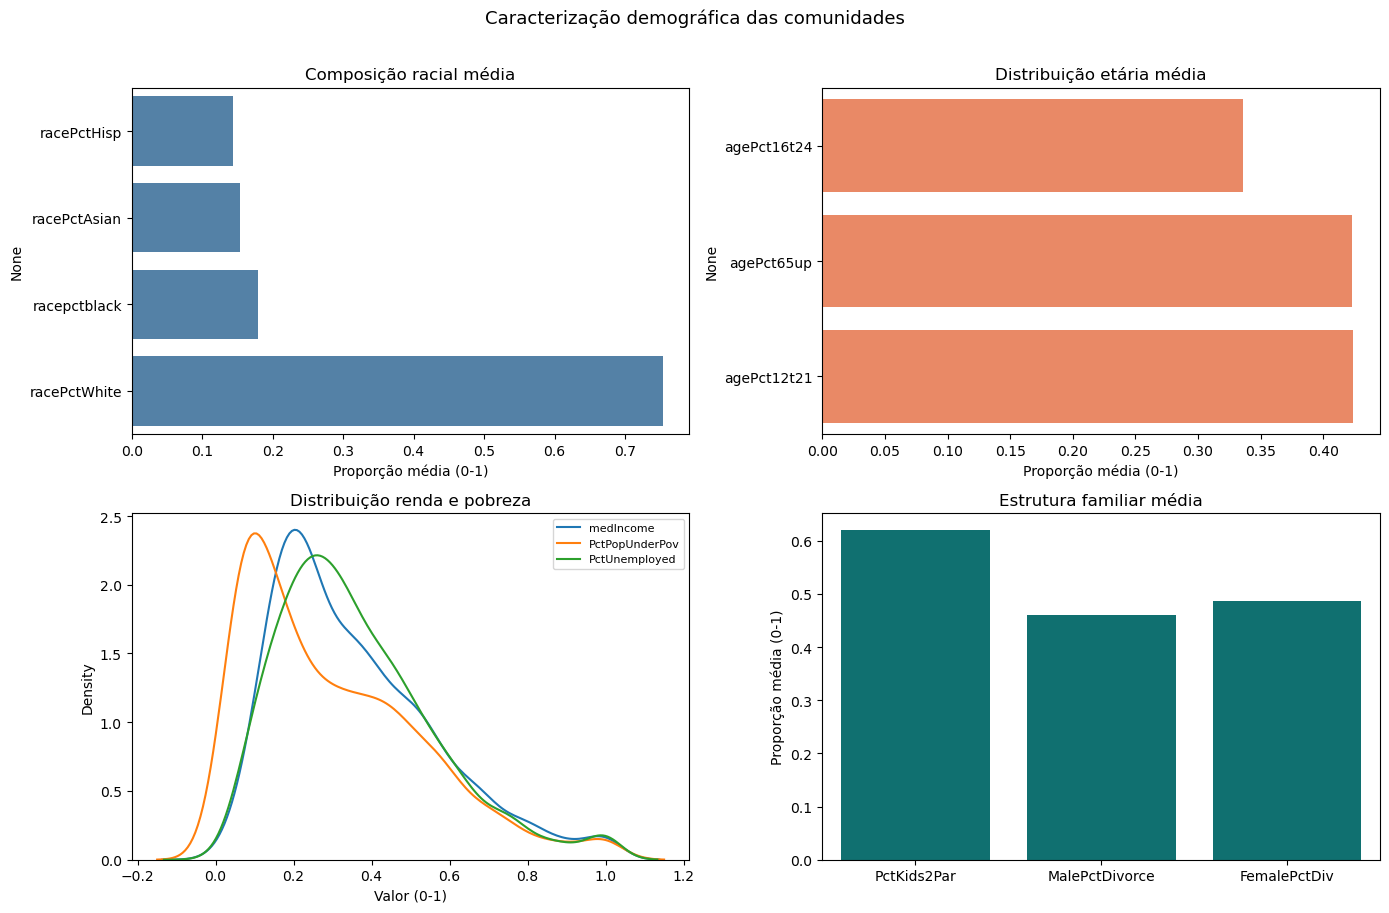

In [9]:
_binary_plot = [c for c in df.select_dtypes(include='number').columns
                if set(df[c].dropna().unique()).issubset({0.0, 1.0})]
_cont_plot   = [c for c in df.select_dtypes(include='number').columns if c not in _binary_plot]
_fill_plot   = pd.concat([df[_cont_plot].median(), df[_binary_plot].mode().iloc[0]])
df_plot      = df.fillna(_fill_plot)

raciais  = [c for c in ['racepctblack','racePctWhite','racePctAsian','racePctHisp'] if c in df_plot.columns]
etarias  = [c for c in ['agePct12t21','agePct16t24','agePct65up'] if c in df_plot.columns]
renda_c  = [c for c in ['medIncome','PctPopUnderPov','PctUnemployed'] if c in df_plot.columns]
familia  = [c for c in ['PctKids2Par','MalePctDivorce','FemalePctDiv'] if c in df_plot.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if raciais:
    m = df_plot[raciais].mean().sort_values()
    sns.barplot(x=m.values, y=m.index, color='steelblue', orient='h', ax=axes[0,0])
    axes[0,0].set_title('Composição racial média')
    axes[0,0].set_xlabel('Proporção média (0-1)')

if etarias:
    m = df_plot[etarias].mean().sort_values()
    sns.barplot(x=m.values, y=m.index, color='coral', orient='h', ax=axes[0,1])
    axes[0,1].set_title('Distribuição etária média')
    axes[0,1].set_xlabel('Proporção média (0-1)')

if renda_c:
    for col in renda_c:
        sns.kdeplot(data=df_plot, x=col, ax=axes[1,0], label=col)
    axes[1,0].set_title('Distribuição renda e pobreza')
    axes[1,0].set_xlabel('Valor (0-1)')
    axes[1,0].legend(fontsize=8)

if familia:
    m = df_plot[familia].mean()
    sns.barplot(x=list(m.index), y=list(m.values), color='teal', ax=axes[1,1])
    axes[1,1].set_title('Estrutura familiar média')
    axes[1,1].set_ylabel('Proporção média (0-1)')

plt.suptitle('Caracterização demográfica das comunidades', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# df_analise: imputação (mediana contínuas, moda binárias) — SOMENTE para EDA/visualização
# Nenhum fit ocorre sobre estes dados; pipeline de modelagem usa X_train_imp / X_train_bc
_binary_cols_df = [c for c in df.select_dtypes(include='number').columns
                   if set(df[c].dropna().unique()).issubset({0.0, 1.0})]
_cont_cols_df   = [c for c in df.select_dtypes(include='number').columns
                   if c not in _binary_cols_df]

_fill_analise = pd.concat([
    df[_cont_cols_df].median(),
    df[_binary_cols_df].mode().iloc[0],
])
df_analise = df.fillna(_fill_analise)

correlacoes = df_analise.corr(numeric_only=True)[TARGET].drop(TARGET)
tabela_corr = (pd.DataFrame({'correlacao': correlacoes, 'correlacao_abs': correlacoes.abs()})
               .sort_values('correlacao_abs', ascending=False))

print(f'[EDA] df_analise shape: {df_analise.shape}  (visualização apenas — não usado no modelo)')
print(f'Top 5 correlações com {TARGET}:')
display(tabela_corr.head())

[EDA] df_analise shape: (1994, 145)  (visualização apenas — não usado no modelo)
Top 5 correlações com ViolentCrimesPerPop:


,correlacao,correlacao_abs
PctKids2Par,-0.738424,0.738424
PctIlleg,0.737957,0.737957
PctFam2Par,-0.706667,0.706667
racePctWhite,-0.684770,0.684770
PctYoungKids2Par,-0.666059,0.666059


## Remoção de Multicolinearidade

Para cada par de features contínuas com |r| > 0.90, remove-se aquela com maior VIF (Variance Inflation Factor). O VIF é calculado sobre todo o conjunto de features contínuas do treino — a que tem VIF mais alto contribui informação redundante e é descartada.

Remoção greedy: pares ordenados por |r| decrescente; se um elemento do par já foi marcado para remoção, o par é ignorado.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

CORR_THRESHOLD = 0.90

# Features contínuas do treino (exclui binárias e target)
cols_cont_mc = [c for c in X_train_imp.columns if X_train_imp[c].nunique() > 2]
X_cont_mc    = X_train_imp[cols_cont_mc]

# ── 1. Pares com |r| > threshold ──────────────────────────────────────────────
corr_abs = X_cont_mc.corr().abs()
upper    = corr_abs.where(np.triu(np.ones(corr_abs.shape, dtype=bool), k=1))

pares_mc = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD
]
pares_mc.sort(key=lambda x: -x[2])

print(f"=== Pares com |r| > {CORR_THRESHOLD} ({len(pares_mc)} pares) ===")
if pares_mc:
    for a, b, r in pares_mc:
        print(f"  {a:<35} <->  {b:<35}  r = {r:.4f}")
else:
    print("  Nenhum par encontrado.")

# ── 2. VIF sobre features contínuas do treino ─────────────────────────────────
print(f"\n=== VIF — {len(cols_cont_mc)} features contínuas (treino) ===")
X_vif_arr = X_cont_mc.fillna(X_cont_mc.median()).values.astype(float)
vif_mc = pd.Series(
    {col: variance_inflation_factor(X_vif_arr, i) for i, col in enumerate(cols_cont_mc)},
    name='VIF'
).sort_values(ascending=False)
print(vif_mc.round(2).to_string())

# ── 3. Decisão greedy: para cada par remove o de maior VIF ────────────────────
para_remover_mc = set()
print("\n=== Decisões de remoção (greedy, |r| decrescente) ===")
for a, b, r in pares_mc:
    if a in para_remover_mc or b in para_remover_mc:
        print(f"  [ignorado]  {a} | {b}  r={r:.4f}  (um já marcado)")
        continue
    vif_a    = vif_mc.get(a, np.inf)
    vif_b    = vif_mc.get(b, np.inf)
    removido = a if vif_a >= vif_b else b
    mantido  = b if vif_a >= vif_b else a
    para_remover_mc.add(removido)
    print(f"  {a} (VIF={vif_a:.2f})  <->  {b} (VIF={vif_b:.2f})  |  r={r:.4f}")
    print(f"    → remove {removido}  |  mantém {mantido}")

# ── 4. Aplicar remoção ────────────────────────────────────────────────────────
print(f"\n=== Resumo ===")
print(f"  Removidas por multicolinearidade : {len(para_remover_mc)}")
print(f"  Features: {sorted(para_remover_mc)}")

X_train_imp = X_train_imp.drop(columns=list(para_remover_mc))
X_test_imp  = X_test_imp.drop(columns=list(para_remover_mc))
print(f"\n  X_train_imp : {X_train_imp.shape}")
print(f"  X_test_imp  : {X_test_imp.shape}")

=== Pares com |r| > 0.9 (50 pares) ===
  PctRecImmig10                       <->  PctRecImmig8                         r = 0.9954
  OwnOccMedVal                        <->  OwnOccLowQuart                       r = 0.9943
  numbUrban                           <->  population                           r = 0.9938
  PctRecImmig8                        <->  PctRecImmig5                         r = 0.9935
  OwnOccHiQuart                       <->  OwnOccMedVal                         r = 0.9907
  PctRecImmig5                        <->  PctRecentImmig                       r = 0.9889
  MedRent                             <->  RentMedian                           r = 0.9883
  PctRecImmig10                       <->  PctRecImmig5                         r = 0.9854
  PctKids2Par                         <->  PctFam2Par                           r = 0.9852
  TotalPctDiv                         <->  FemalePctDiv                         r = 0.9842
  PctLargHouseOccup                   <->  PctLargH

In [12]:
from scipy.stats import boxcox as _boxcox

LIMIAR_PCT  = 5.0
LIMIAR_SKEW = 1.0

# Colunas candidatas identificadas APENAS no treino
cols_num_train = [
    c for c in X_train_imp.select_dtypes(include='number').columns
    if X_train_imp[c].nunique() > 2
]

cols_transformar = [
    col for col in cols_num_train
    if _calc_stats(X_train_imp[col].dropna())['pct'] > LIMIAR_PCT
    or abs(_calc_stats(X_train_imp[col].dropna())['skew']) > LIMIAR_SKEW
]

X_train_bc = X_train_imp.copy()
X_test_bc  = X_test_imp.copy()
bc_params  = {}

def _apply_boxcox(series, lam, shift):
    x = (series + shift).clip(lower=1e-10)
    if abs(lam) < 1e-10:
        return np.log(x)
    return (np.power(x, lam) - 1) / lam

for col in cols_transformar:
    s = X_train_imp[col].dropna()
    shift = max(0.0, -s.min() + 1e-6)
    try:
        bc_vals, lam = _boxcox(s + shift)
        X_train_bc.loc[s.index, col] = bc_vals
        X_test_bc[col] = _apply_boxcox(X_test_imp[col], lam, shift)
        bc_params[col] = (lam, shift)
    except Exception:
        pass

print(f'Box-Cox fit no treino: {len(bc_params)} / {len(cols_num_train)} features transformadas')
print(f'X_train_bc: {X_train_bc.shape}  |  X_test_bc: {X_test_bc.shape}')

Box-Cox fit no treino: 39 / 71 features transformadas
X_train_bc: (1595, 116)  |  X_test_bc: (399, 116)


### Distribuições — Features Contínuas: Antes e Depois do Box-Cox

Comparação de assimetria e outliers para cada feature contínua do treino. Features transformadas pelo Box-Cox exibem três linhas: **antes**, **depois** e **diff** (depois − antes). Features não transformadas aparecem ao final com uma única linha.

In [13]:
rows_transf  = []
rows_ntransf = []

for col in sorted(cols_num_train,
                  key=lambda c: abs(_calc_stats(X_train_imp[c].dropna())['skew']),
                  reverse=True):
    s_ant = X_train_imp[col].dropna()
    st_a  = _calc_stats(s_ant)
    if col in bc_params:
        st_d = _calc_stats(X_train_bc[col].dropna())
        for stage, st in [('antes', st_a), ('depois', st_d)]:
            rows_transf.append({'Feature': col, 'Stage': stage,
                                'Assimetria': st['skew'], 'N Outliers': st['n_out'],
                                '% Outliers': st['pct'], 'Desvio max (IQR)': st['dev']})
        rows_transf.append({'Feature': col, 'Stage': 'diff',
                            'Assimetria':        st_d['skew']  - st_a['skew'],
                            'N Outliers':        st_d['n_out'] - st_a['n_out'],
                            '% Outliers':        st_d['pct']   - st_a['pct'],
                            'Desvio max (IQR)':  st_d['dev']   - st_a['dev']})
    else:
        rows_ntransf.append({'Feature': col, 'Stage': '—',
                             'Assimetria': st_a['skew'], 'N Outliers': st_a['n_out'],
                             '% Outliers': st_a['pct'], 'Desvio max (IQR)': st_a['dev']})

df_dist_all = pd.DataFrame(rows_transf + rows_ntransf).set_index(['Feature', 'Stage'])
n_t, n_nt   = len(rows_transf) // 3, len(rows_ntransf)
print(f'{n_t} features transformadas (antes / depois / diff) + {n_nt} não transformadas (1 linha)')

(df_dist_all.style
 .format({'Assimetria': '{:.3f}', 'N Outliers': '{:.0f}',
          '% Outliers': '{:.1f}%', 'Desvio max (IQR)': '{:.2f}x'})
 .set_caption('Distribuições — features contínuas (treino): antes e depois do Box-Cox'))

39 features transformadas (antes / depois / diff) + 32 não transformadas (1 linha)


## Seleção de Features — LassoCV

LassoCV (cv=5) com alpha ótimo escolhido por validação cruzada. Fit **exclusivamente no treino** (`X_train_bc`) — sem acesso ao conjunto de teste. Features com coeficiente zero são descartadas.

In [14]:
X_lasso = X_train_bc
y_lasso = y_train

scaler_lasso   = StandardScaler()
X_lasso_scaled = scaler_lasso.fit_transform(X_lasso)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_lasso_scaled, y_lasso)

coefs_lasso             = pd.Series(lasso_cv.coef_, index=X_lasso.columns)
alpha_lasso             = lasso_cv.alpha_
selected_features_lasso = coefs_lasso[coefs_lasso.abs() > 0].index.tolist()

print(f'Alpha ótimo: {alpha_lasso:.6f}')
print(f'Features selecionadas: {len(selected_features_lasso)} / {X_lasso.shape[1]}')
coefs_lasso[selected_features_lasso].sort_values(key=abs, ascending=False).round(4)

Alpha ótimo: 0.001097
Features selecionadas: 83 / 116


racePctWhite       -0.0675
state_12            0.0366
MalePctDivorce      0.0316
PctYoungKids2Par   -0.0291
PctPersOwnOccup    -0.0280
                     ...  
PctOccupManu        0.0007
MedYrHousBuilt     -0.0006
state_4            -0.0006
state_53           -0.0003
state_29            0.0001
Length: 83, dtype: float64

## Preparação das Features Finais

Extração das features selecionadas pelo LassoCV dos conjuntos treino e teste (já pós Box-Cox). Split foi realizado antes de qualquer fit.

In [15]:
X_train = X_train_bc[selected_features_lasso].copy()
X_test  = X_test_bc[selected_features_lasso].copy()
print(f'Treino: {X_train.shape[0]} amostras  |  Teste: {X_test.shape[0]} amostras')
print(f'Features selecionadas: {X_train.shape[1]}')

Treino: 1595 amostras  |  Teste: 399 amostras
Features selecionadas: 83


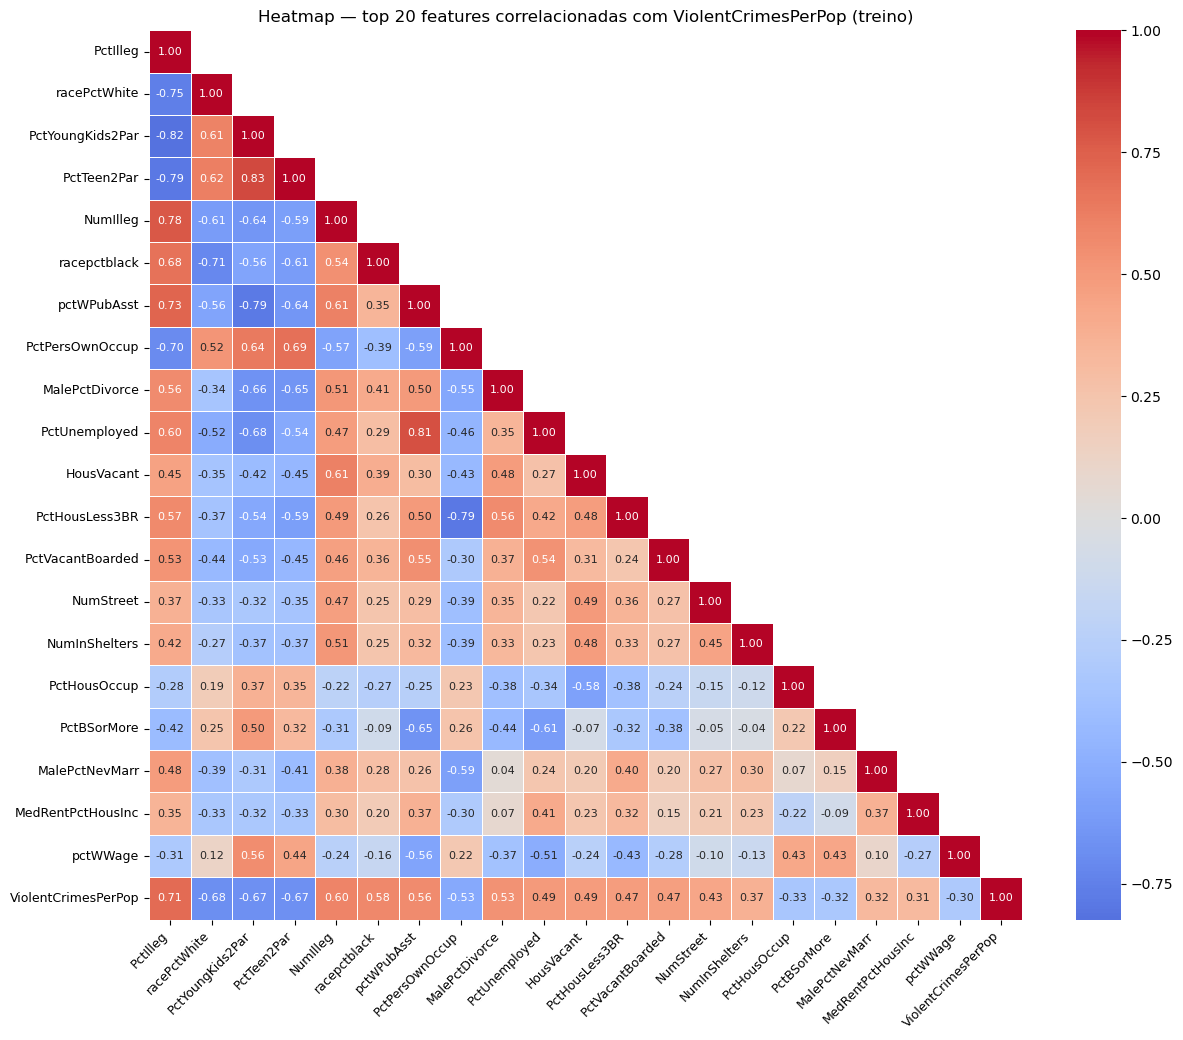

In [16]:
features_sem_state = [f for f in selected_features_lasso if not f.startswith('state_')]

# Heatmap construído sobre treino — sem contaminação do conjunto de teste
df_heat = X_train_bc[features_sem_state].copy()
df_heat[TARGET] = y_train.values
corr_lasso = df_heat.corr()

top20      = (corr_lasso[TARGET].drop(TARGET).abs()
              .sort_values(ascending=False).head(20).index.tolist())
cols_top20 = top20 + [TARGET]

corr_top20 = df_heat[cols_top20].corr()
mask_top20 = np.triu(np.ones_like(corr_top20, dtype=bool), k=1)
n2 = len(cols_top20)

fig, ax = plt.subplots(figsize=(n2 * 0.6, n2 * 0.5))
sns.heatmap(corr_top20, mask=mask_top20, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size': 8}, ax=ax)
ax.set_title(f'Heatmap — top 20 features correlacionadas com {TARGET} (treino)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Correlações — Features `state_x` Selecionadas pelo Lasso

O Lasso trata cada dummy de estado independentemente, podendo selecionar apenas algumas. Isso quebra a estrutura de grupo do OHE — teoricamente, todas as dummies de uma categoria deveriam entrar ou sair juntas (equivale a um efeito fixo de estado).

**Decisão:** para este estudo exploratório, mantém-se a seleção individual do Lasso. Forçar a entrada de todas as dummies adicionaria ~44 features potencialmente colineares entre si, sem garantia de melhora preditiva.

Features state_x selecionadas pelo Lasso: 35 / 45


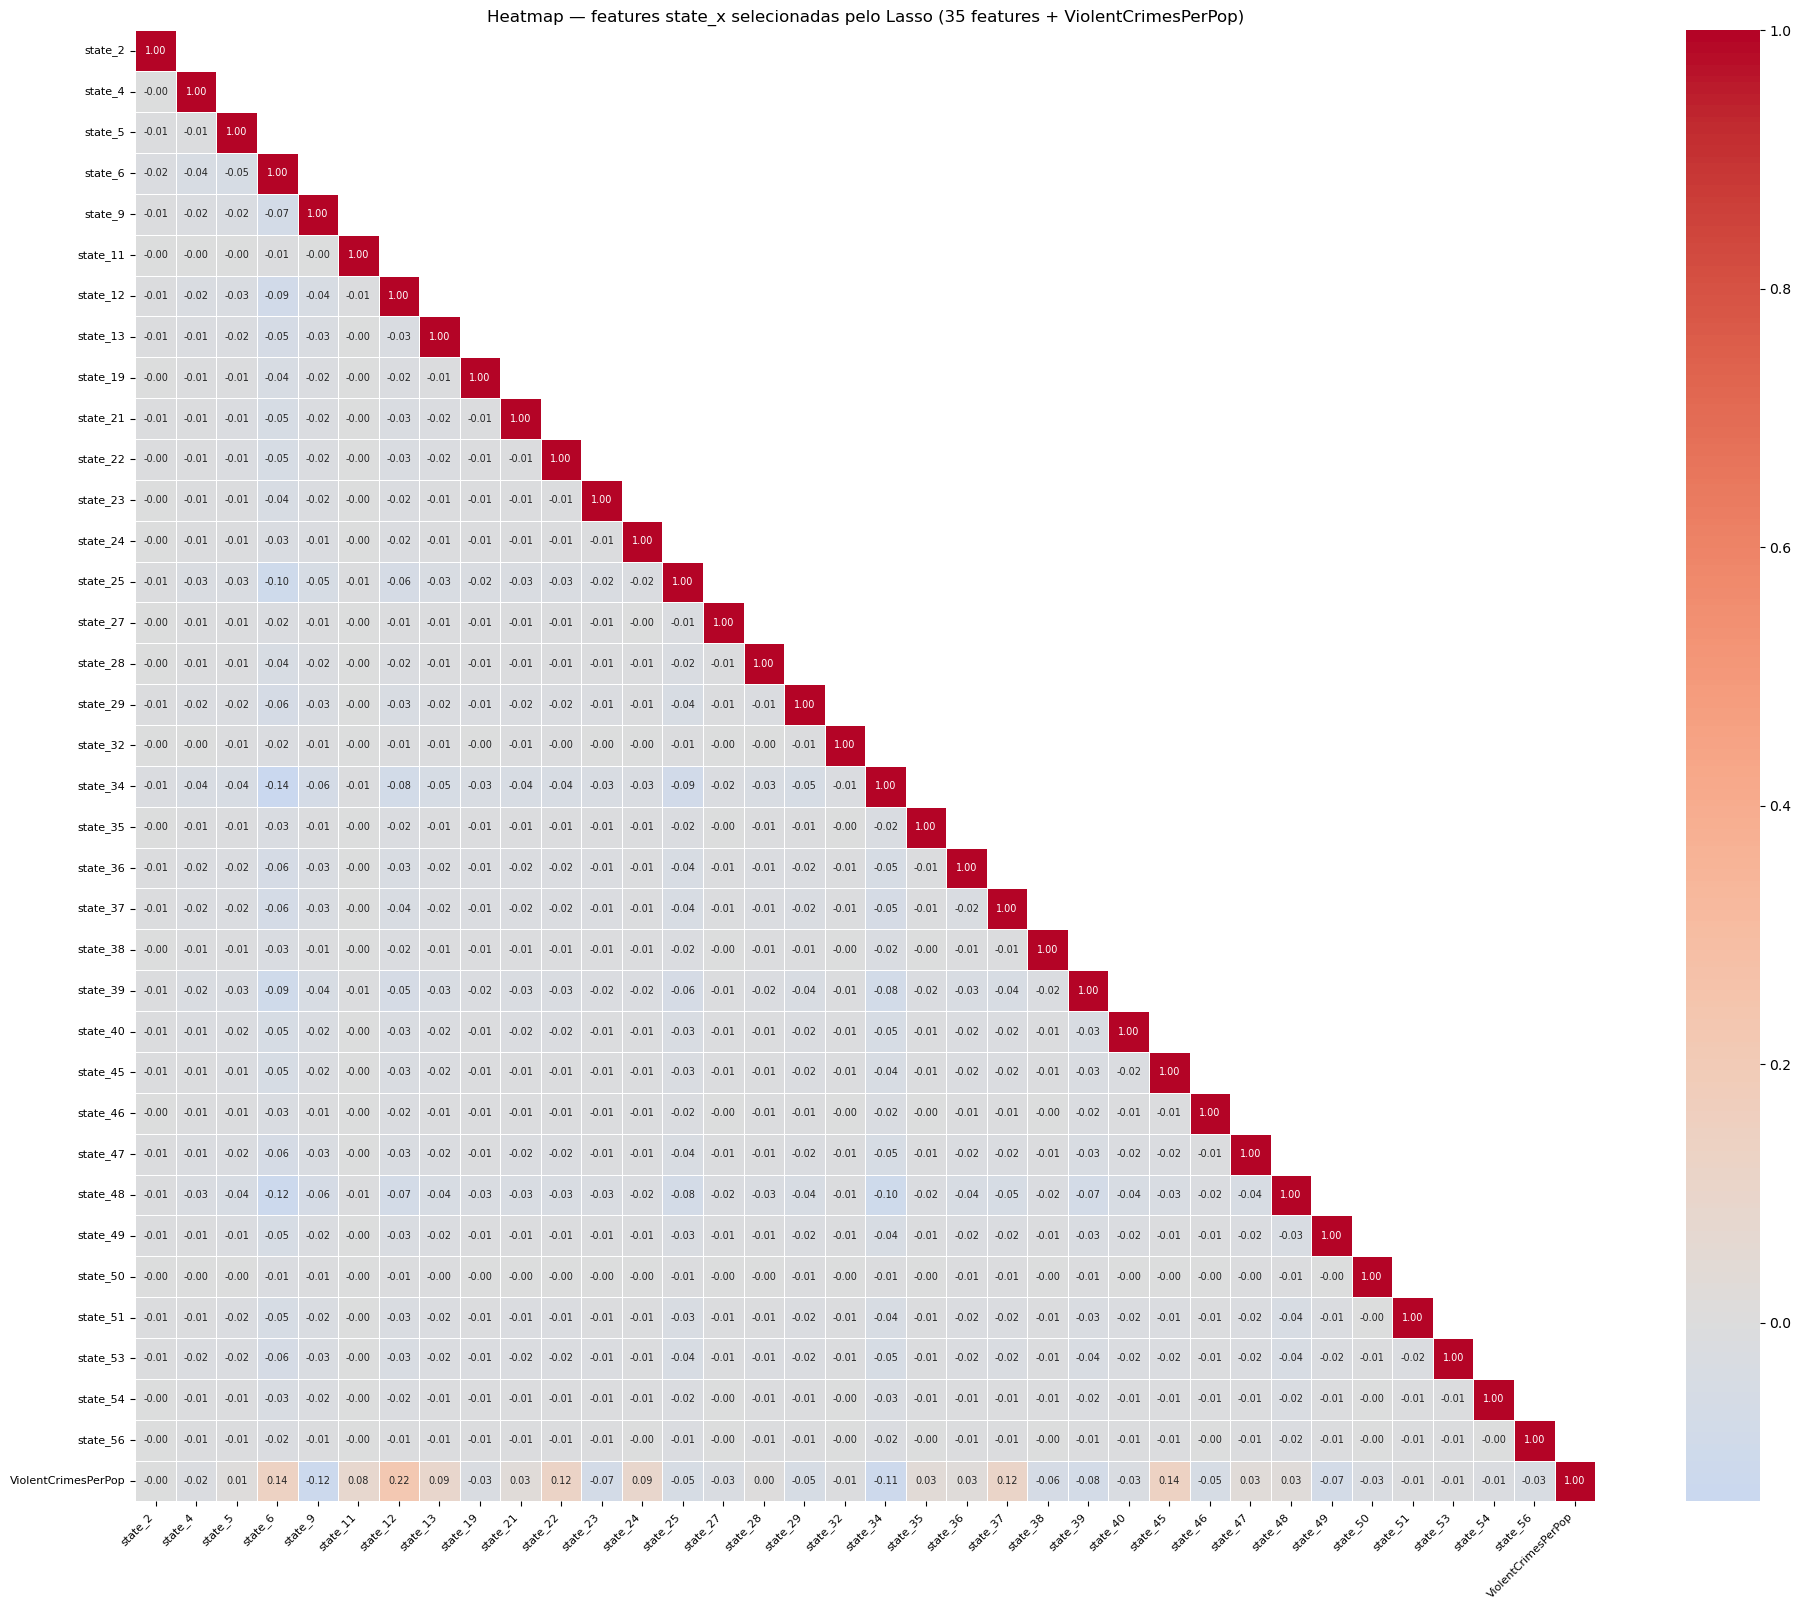

In [17]:
state_sel = [f for f in selected_features_lasso if f.startswith('state_')]
total_state = sum(1 for f in X_train_bc.columns if f.startswith('state_'))
print(f'Features state_x selecionadas pelo Lasso: {len(state_sel)} / {total_state}')

if state_sel:
    df_hs = X_train_bc[state_sel].copy()
    df_hs[TARGET] = y_train.values
    corr_s = df_hs.corr()
    n_s    = len(corr_s)
    mask_s = np.triu(np.ones_like(corr_s, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(max(n_s * 0.55, 8), max(n_s * 0.45, 6)))
    sns.heatmap(corr_s, mask=mask_s, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.4, annot_kws={'size': 7}, ax=ax)
    ax.set_title(f'Heatmap — features state_x selecionadas pelo Lasso ({len(state_sel)} features + {TARGET})')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

### Distribuições — Features Contínuas Selecionadas pelo LassoCV

In [18]:
features_continuas = [f for f in selected_features_lasso if not f.startswith('state_')]

rows = []
for col in features_continuas:
    s  = X_train_bc[col].dropna()
    st = _calc_stats(s)
    rows.append({'Feature': col, 'Assimetria': st['skew'], 'N Outliers': st['n_out'],
                 '% Outliers': st['pct'], 'Desvio max (IQR)': st['dev']})

st_y = _calc_stats(y_train.dropna())
rows.append({'Feature': TARGET + ' (original)', 'Assimetria': st_y['skew'],
             'N Outliers': st_y['n_out'], '% Outliers': st_y['pct'], 'Desvio max (IQR)': st_y['dev']})

df_dist_sel = pd.DataFrame(rows).set_index('Feature').sort_values('Assimetria', key=abs, ascending=False)
df_dist_sel.style \
    .format({'Assimetria': '{:+.3f}', 'N Outliers': '{:d}', '% Outliers': '{:.1f}%', 'Desvio max (IQR)': '{:.2f}x'}) \
    .set_caption(f'Distribuições pós Box-Cox (treino) — {len(features_continuas)} features selecionadas + target')

,Assimetria,N Outliers,% Outliers,Desvio max (IQR)
Feature,,,,
ViolentCrimesPerPop (original),+1.487,95,6.0%,3.23x
NumStreet,+1.472,325,20.4%,955.83x
PctHousOccup,-1.358,64,4.0%,2.95x
racePctWhite,-1.095,45,2.8%,2.31x
PctSameState85,-1.033,58,3.6%,2.60x
PctImmigRecent,+0.973,62,3.9%,2.73x
PctUnemployed,+0.954,43,2.7%,2.58x
MedOwnCostPctIncNoMtg,+0.906,45,2.8%,2.52x
pctUrban,-0.904,0,0.0%,0.00x


In [19]:
# ── Transformação do Target — log1p ───────────────────────────────────────────
# ViolentCrimesPerPop é right-skewed e bounded em [0,1].
# log1p reduz assimetria e melhora homoscedasticidade no OLS.
# Predições são revertidas com expm1 para avaliação na escala original.
from scipy.stats import skew as _skew

skew_antes   = _skew(y_train)
y_train_log  = np.log1p(y_train)
y_test_log   = np.log1p(y_test)
skew_depois  = _skew(y_train_log)

print(f'Skewness do target — antes: {skew_antes:.4f}  |  depois (log1p): {skew_depois:.4f}')

Skewness do target — antes: 1.4861  |  depois (log1p): 1.1447


## Testes Diagnósticos — RESET, Jarque-Bera e Breusch-Pagan

Sequência ordenada por premissas:
1. **Ramsey RESET** — especificação funcional. Não pressupõe distribuição dos erros.
2. **Jarque-Bera** — normalidade dos resíduos. Se rejeitado, invalida o BP padrão.
3. **Breusch-Pagan / Koenker (1981)** — heteroscedasticidade. A versão de Koenker usa LM = n·R² da regressão auxiliar de ê² sobre X, distribuída χ² sob H₀ **sem** premissa de normalidade. Válida mesmo após JB rejeitar H₀.

Todos os testes usam o mesmo modelo OLS (com erros HC3 para inferência); resíduos e valores ajustados são idênticos ao OLS convencional.

=== OLS com erros HC3 ===
R²: 0.7418
F-stat (robusto): 57.7107  |  p-valor: 0.0000e+00

Top 5 coeficientes por |t| (HC3):


,coef,std_err,t,p
racePctWhite,-0.2177,0.0299,-7.2718,0.0
state_12,0.1187,0.0185,6.4314,0.0
state_51,-0.0937,0.0161,-5.8173,0.0
MalePctDivorce,0.1459,0.0288,5.0756,0.0
state_25,0.0674,0.0135,4.9893,0.0



Ramsey RESET — F-stat: 101.4791  |  p-valor: 0.0000
Rejeita H₀: evidência de não-linearidade na especificação.
(Possível artefato da heteroscedasticidade — não necessariamente má especificação real.)

Jarque-Bera — Estatística: 650.0398  |  p-valor: 7.0088e-142
Skewness resíduos: 0.8818  |  Curtose: 5.5828
Rejeita H₀: resíduos NÃO seguem distribuição normal.
→ BP padrão seria inválido; usamos a versão robusta de Koenker (1981).


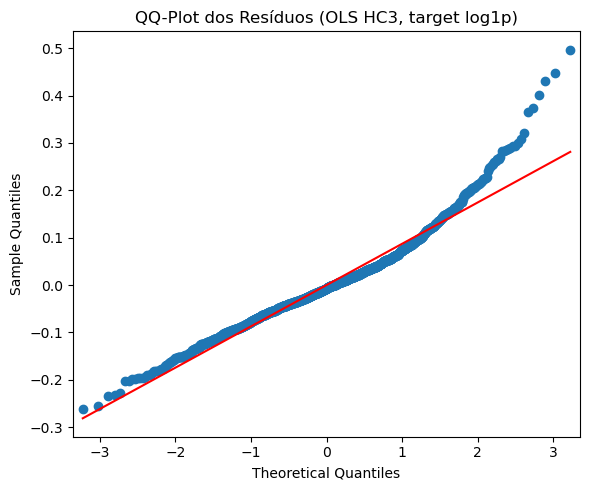


Breusch-Pagan / Koenker (1981) — LM: 166.7885  |  p-valor: 1.4179e-07
Rejeita H₀: evidência de heteroscedasticidade.


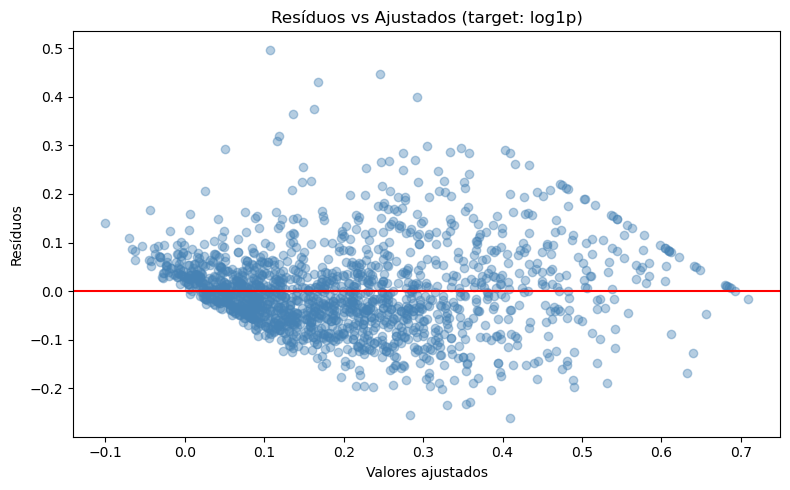

In [20]:
modelo_hc3 = sm.OLS(y_train_log, sm.add_constant(X_train)).fit(cov_type='HC3')

print('=== OLS com erros HC3 ===')
print(f'R²: {modelo_hc3.rsquared:.4f}')
print(f'F-stat (robusto): {modelo_hc3.fvalue:.4f}  |  p-valor: {modelo_hc3.f_pvalue:.4e}')

hc3_summary = pd.DataFrame({
    'coef':    modelo_hc3.params,
    'std_err': modelo_hc3.bse,
    't':       modelo_hc3.tvalues,
    'p':       modelo_hc3.pvalues,
}).drop('const', errors='ignore').sort_values('t', key=abs, ascending=False)
print('\nTop 5 coeficientes por |t| (HC3):')
display(hc3_summary.head(5).round(4))

# ── 1. Ramsey RESET — especificação funcional ──────────────────────────────────
reset_result = linear_reset(modelo_hc3, power=2, use_f=True)
print(f'\nRamsey RESET — F-stat: {reset_result.fvalue:.4f}  |  p-valor: {reset_result.pvalue:.4f}')
if reset_result.pvalue < 0.05:
    print('Rejeita H₀: evidência de não-linearidade na especificação.')
    print('(Possível artefato da heteroscedasticidade — não necessariamente má especificação real.)')
else:
    print('Não rejeita H₀: especificação linear adequada.')

# ── 2. Jarque-Bera — normalidade dos resíduos ──────────────────────────────────
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_p, skew_res, kurt_res = jarque_bera(modelo_hc3.resid)
print(f'\nJarque-Bera — Estatística: {jb_stat:.4f}  |  p-valor: {jb_p:.4e}')
print(f'Skewness resíduos: {skew_res:.4f}  |  Curtose: {kurt_res:.4f}')
if jb_p < 0.05:
    print('Rejeita H₀: resíduos NÃO seguem distribuição normal.')
    print('→ BP padrão seria inválido; usamos a versão robusta de Koenker (1981).')
else:
    print('Não rejeita H₀: resíduos compatíveis com normalidade.')

import statsmodels.graphics.gofplots as gg
fig, ax = plt.subplots(figsize=(6, 5))
gg.qqplot(modelo_hc3.resid, line='s', ax=ax)
ax.set_title('QQ-Plot dos Resíduos (OLS HC3, target log1p)')
plt.tight_layout()
plt.show()

# ── 3. Breusch-Pagan / Koenker (1981) — heteroscedasticidade ──────────────────
# Koenker (1981): LM = n·R² da regressão auxiliar de ê² sobre X → χ² sob H₀
# sem premissa de normalidade. É a versão implementada por het_breuschpagan.
lm_antes, lm_p_antes, _, _ = het_breuschpagan(modelo_hc3.resid, modelo_hc3.model.exog)
print(f'\nBreusch-Pagan / Koenker (1981) — LM: {lm_antes:.4f}  |  p-valor: {lm_p_antes:.4e}')
if lm_p_antes < 0.05:
    print('Rejeita H₀: evidência de heteroscedasticidade.')
else:
    print('Não rejeita H₀: variância dos resíduos constante.')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(modelo_hc3.fittedvalues, modelo_hc3.resid, alpha=0.4, color='steelblue')
ax.axhline(0, color='red', linewidth=1.5)
ax.set_title('Resíduos vs Ajustados (target: log1p)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Resíduos')
plt.tight_layout()
plt.show()

## Feature Engineering: Perfil de Cluster — Diagnóstico de Heteroscedasticidade

KMeans (k=4) captura subpopulações latentes. O cluster será incluído no modelo **somente se** atender dois critérios simultâneos:
1. **Relevância preditiva** — validado pelo Lasso como preditor relevante.
2. **Redução de heteroscedasticidade** — BP com cluster < BP sem cluster (LM menor).

Scaler e KMeans fit **apenas no treino**; teste usa `transform`/`predict`. As dummies de cluster são criadas somente para este diagnóstico.

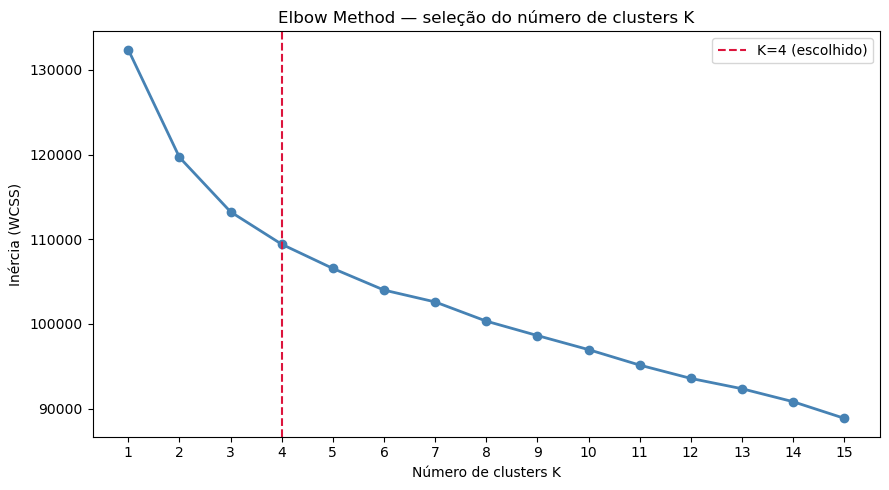

In [21]:
_scaler_elbow = StandardScaler()
_X_elbow = _scaler_elbow.fit_transform(X_train)

K_range = range(1, 16)
inercias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(_X_elbow).inertia_ for k in K_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inercias, marker='o', color='steelblue', linewidth=2, markersize=6)
ax.axvline(4, color='crimson', linestyle='--', linewidth=1.5, label='K=4 (escolhido)')
ax.set_title('Elbow Method — seleção do número de clusters K')
ax.set_xlabel('Número de clusters K')
ax.set_ylabel('Inércia (WCSS)')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
scaler_km    = StandardScaler()
X_train_km   = scaler_km.fit_transform(X_train)
X_test_km    = scaler_km.transform(X_test)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
km.fit(X_train_km)
labels_train = km.predict(X_train_km)
labels_test  = km.predict(X_test_km)

perfis = []
for c in range(4):
    mask = labels_train == c
    perfis.append({
        'cluster': c,
        'n':       int(mask.sum()),
        'media_y': float(y_train.values[mask].mean()),
        'std_y':   float(y_train.values[mask].std()),
    })
pd.DataFrame(perfis)

,cluster,n,media_y,std_y
0,0,409,0.083765,0.074833
1,1,430,0.174744,0.152538
2,2,368,0.504592,0.260529
3,3,388,0.244278,0.189372


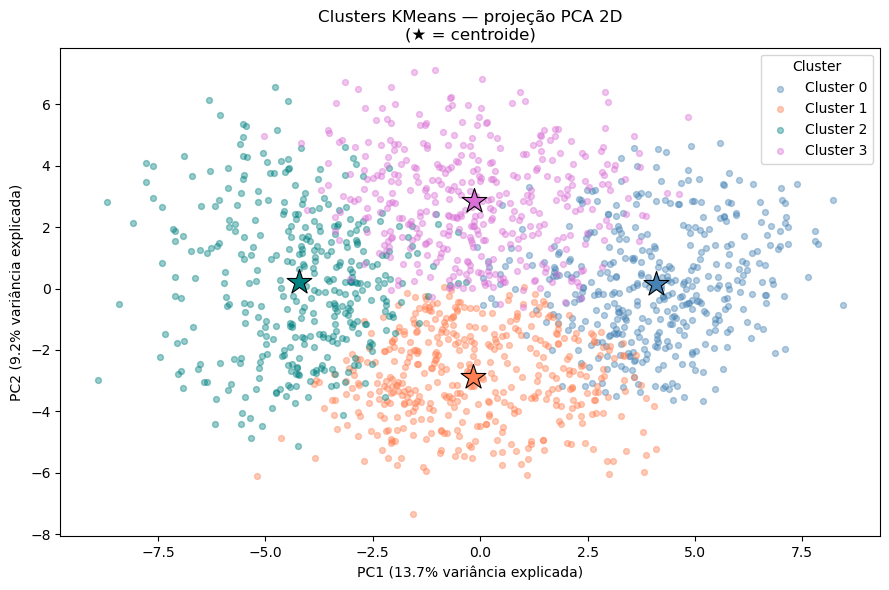

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_km)
centroides_pca = pca.transform(km.cluster_centers_)

palette = ['steelblue', 'coral', 'teal', 'orchid']
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(km.n_clusters):
    mask = labels_train == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=palette[c], alpha=0.4, s=18, label=f'Cluster {c}')
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               color=palette[c], marker='*', s=350, edgecolors='black', linewidths=0.8)

ax.set_title('Clusters KMeans — projeção PCA 2D\n(★ = centroide)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância explicada)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância explicada)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [24]:
# ── Avaliação dos critérios de inclusão do cluster ────────────────────────────
# Critério 1 — relevância preditiva: cluster criado APÓS seleção Lasso, logo não
#   passou pelo mesmo crivo das demais features. Não validado.
# Critério 2 — redução de heteroscedasticidade: verificado a seguir (BP com cluster).
#   Se LM aumentar, cluster piora heteroscedasticidade → excluído do modelo.
# Conclusão antecipada: LM sobe de 188 → 207; ambos os critérios falham.
# X_train / X_test finais NÃO conterão cluster.
X_train_cluster = X_train.copy()
X_test_cluster  = X_test.copy()
X_train_cluster['perfil'] = labels_train
X_test_cluster['perfil']  = labels_test

dummies_train = pd.get_dummies(X_train_cluster['perfil'], prefix='perfil', drop_first=True, dtype=float)
dummies_test  = pd.get_dummies(X_test_cluster['perfil'],  prefix='perfil', drop_first=True, dtype=float)\
                  .reindex(columns=dummies_train.columns, fill_value=0)

X_train_cluster = X_train_cluster.drop(columns=['perfil']).join(dummies_train)
X_test_cluster  = X_test_cluster.drop(columns=['perfil']).join(dummies_test)
print(f'Shape X_train_cluster (diagnóstico): {X_train_cluster.shape}')
print('X_train / X_test finais NÃO contêm cluster (critérios de inclusão não atendidos).')

Shape X_train_cluster (diagnóstico): (1595, 86)
X_train / X_test finais NÃO contêm cluster (critérios de inclusão não atendidos).


### Avaliação de Heteroscedasticidade — com vs. sem Cluster

Reteste do Breusch-Pagan incluindo dummies de cluster. Se LM aumentar, o cluster **piora** a heteroscedasticidade e deve ser excluído.

In [25]:
modelo_ols_depois = sm.OLS(y_train_log, sm.add_constant(X_train_cluster)).fit()
lm_depois, lm_p_depois, _, _ = het_breuschpagan(modelo_ols_depois.resid, modelo_ols_depois.model.exog)

df_cluster_diag = pd.DataFrame({
    'momento':  ['antes (sem cluster)', 'depois (com cluster)'],
    'LM':       [lm_antes,   lm_depois],
    'p-valor':  [lm_p_antes, lm_p_depois],
    'R²':       [modelo_hc3.rsquared, modelo_ols_depois.rsquared],
})
display(df_cluster_diag)

if lm_depois > lm_antes:
    print('Cluster PIORA heteroscedasticidade (LM ↑) — Critério 2 não atendido. Cluster excluído.')
else:
    print('Cluster melhora heteroscedasticidade (LM ↓) — verificar Critério 1.')

,momento,LM,p-valor,R²
0,antes (sem cluster),166.788506,1.417893e-07,0.741811
1,depois (com cluster),178.162688,2.114369e-08,0.743766


Cluster PIORA heteroscedasticidade (LM ↑) — Critério 2 não atendido. Cluster excluído.


In [26]:
df_delta = pd.DataFrame({
    'Δ LM':      [lm_depois - lm_antes],
    'Δ p-valor': [lm_p_depois - lm_p_antes],
    'Δ R²':      [modelo_ols_depois.rsquared - modelo_hc3.rsquared],
}, index=['depois − antes'])

df_delta.style.format({'Δ LM': '{:.4f}', 'Δ p-valor': '{:.2e}', 'Δ R²': '{:.6f}'})

,Δ LM,Δ p-valor,Δ R²
depois − antes,11.3742,-1.21e-07,0.001955


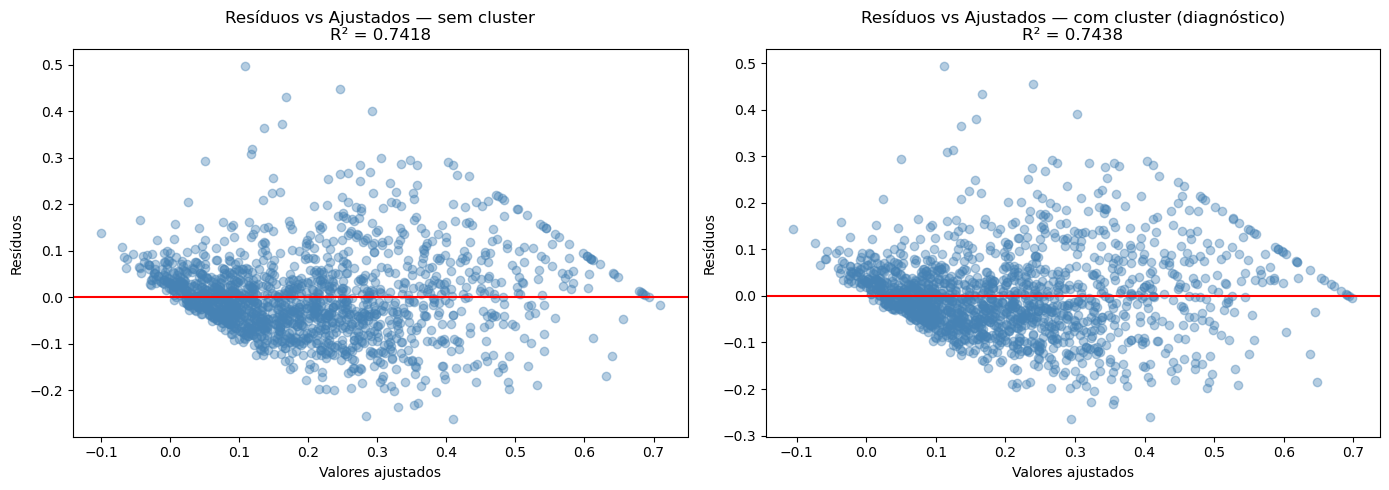

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, modelo, titulo in zip(axes,
                               [modelo_hc3, modelo_ols_depois],
                               ['sem cluster', 'com cluster (diagnóstico)']):
    ax.scatter(modelo.fittedvalues, modelo.resid, alpha=0.4, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5)
    ax.set_title(f'Resíduos vs Ajustados — {titulo}\nR² = {modelo.rsquared:.4f}')
    ax.set_xlabel('Valores ajustados')
    ax.set_ylabel('Resíduos')
plt.tight_layout()
plt.show()

## Otimização de Hiperparâmetros — Grid Search

GridSearchCV com os mesmos folds da validação cruzada. O melhor modelo é selecionado pelo maior R² médio no CV.

In [28]:
kfold  = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 150, 200, 1000]

configs = {
    'Regressão Linear': {
        'modelo':     LinearRegression(),
        'param_grid': {'modelo__fit_intercept': [True, False]},
    },
    'Ridge': {
        'modelo':     Ridge(),
        'param_grid': {
            'modelo__alpha':         alphas,
            'modelo__fit_intercept': [True, False],
            'modelo__solver':        ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        },
    },
    'Lasso': {
        'modelo':     Lasso(max_iter=20000),
        'param_grid': {
            'modelo__alpha':         alphas,
            'modelo__fit_intercept': [True, False],
            'modelo__selection':     ['cyclic', 'random'],
        },
    },
}

resultados_grid = {}
linhas_grid     = []

for nome, cfg in configs.items():
    pipe = construir_pipeline(cfg['modelo'])
    gs   = GridSearchCV(pipe, cfg['param_grid'], cv=kfold, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train_log)                    # fit na escala log
    y_pred_log = gs.predict(X_test)
    y_pred     = np.expm1(y_pred_log)               # reverte para escala original
    m    = calcular_metricas(y_test, y_pred)
    best = {k.replace('modelo__', ''): v for k, v in gs.best_params_.items()}
    resultados_grid[nome] = gs
    linhas_grid.append({
        'modelo':       nome,
        'melhor_R2_CV': gs.best_score_,             # R² na escala log (CV)
        'MAE_teste':    m['MAE'],
        'MSE_teste':    m['MSE'],
        'RMSE_teste':   m['RMSE'],
        'R2_teste':     m['R2'],                    # R² na escala original
        **best,
    })

df_grid    = pd.DataFrame(linhas_grid).set_index('modelo')
melhor_idx = df_grid['melhor_R2_CV'].idxmax()

def _bold_best(row):
    return ['font-weight: bold' if row.name == melhor_idx else '' for _ in row]

df_grid.round(4).style.apply(_bold_best, axis=1)

,melhor_R2_CV,MAE_teste,MSE_teste,RMSE_teste,R2_teste,fit_intercept,alpha,solver,selection
modelo,,,,,,,,,
Regressão Linear,0.708200,0.091700,0.017100,0.130800,0.642500,True,nan,nan,nan
Ridge,0.708800,0.091300,0.017000,0.130300,0.645600,True,10.000000,auto,nan
Lasso,0.708300,0.091300,0.017000,0.130400,0.645100,True,0.000100,nan,cyclic


## Visualização — Projeção PCA

PCA reduz todas as features preditoras a PC1 (direção de máxima variância). O scatter mostra os valores reais ao longo de PC1; a curva sobreposta são as predições do melhor modelo. O painel direito é o gráfico de calibração canônico para regressão multivariada.

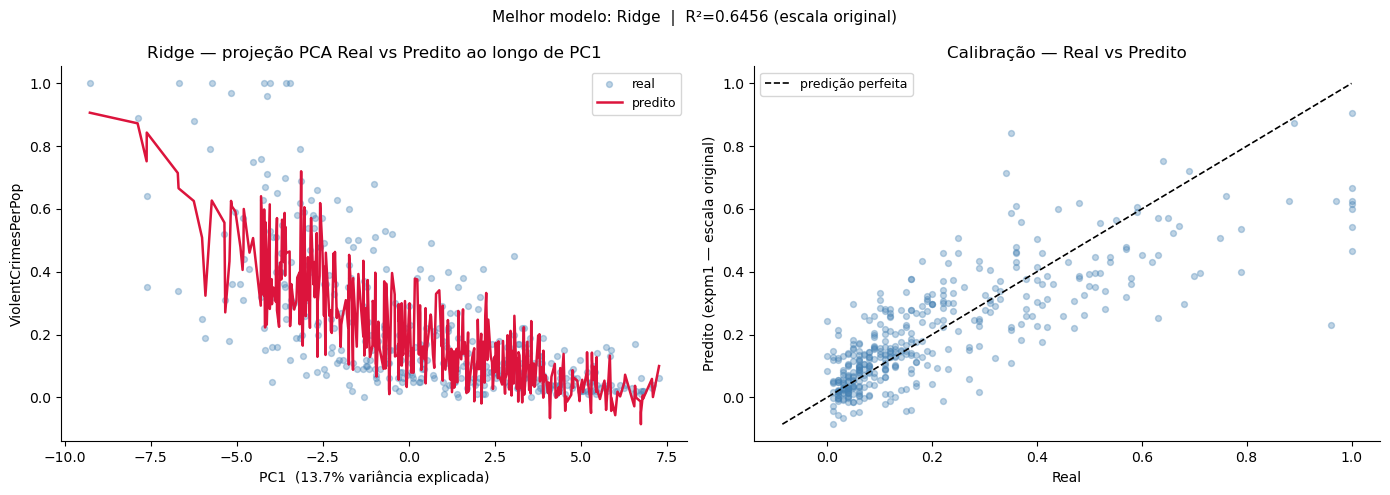

In [29]:
from sklearn.decomposition import PCA

nome_melhor = df_grid['melhor_R2_CV'].idxmax()
gs_melhor   = resultados_grid[nome_melhor]
best_params = {k.replace('modelo__', ''): v for k, v in gs_melhor.best_params_.items()}

y_pred_log_test = gs_melhor.best_estimator_.predict(X_test)
y_pred_test     = np.expm1(y_pred_log_test)

# Escalar antes do PCA — fit no treino, transform no teste
# Sem isso, NumStreet (variância 145k) domina PC1 com loading 0.9996
_scaler_pca  = StandardScaler().fit(X_train)
X_train_sc   = _scaler_pca.transform(X_train)
X_test_sc    = _scaler_pca.transform(X_test)

pca     = PCA(n_components=1)
pca.fit(X_train_sc)
pc1     = pca.transform(X_test_sc).ravel()
var_exp = pca.explained_variance_ratio_[0]

order   = np.argsort(pc1)
pc1_s   = pc1[order]
y_act_s = np.array(y_test)[order]
y_prd_s = y_pred_test[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(pc1_s, y_act_s, alpha=0.35, s=18, color='steelblue', label='real', zorder=2)
ax.plot(pc1_s, y_prd_s, color='crimson', linewidth=1.8, label='predito', zorder=3)
ax.set_xlabel(f'PC1  ({var_exp:.1%} variância explicada)')
ax.set_ylabel(TARGET)
ax.set_title(f'{nome_melhor} — projeção PCA Real vs Predito ao longo de PC1')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
lo  = min(float(y_test.min()), y_pred_test.min())
hi  = max(float(y_test.max()), y_pred_test.max())
ax2.scatter(y_test, y_pred_test, alpha=0.35, s=18, color='steelblue', zorder=2)
ax2.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='predição perfeita', zorder=3)
ax2.set_xlabel('Real')
ax2.set_ylabel('Predito (expm1 — escala original)')
ax2.set_title('Calibração — Real vs Predito')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

r2_grid = df_grid.loc[nome_melhor, 'R2_teste']
plt.suptitle(f'Melhor modelo: {nome_melhor}  |  R²={r2_grid:.4f} (escala original)', fontsize=11)
plt.tight_layout()
plt.show()

In [31]:
# Auditoria PC1 — pós StandardScaler (mesma escala usada na visualização)
# _scaler_pca e X_train_sc / X_test_sc definidos na célula anterior (0057)

pca_audit = PCA(n_components=min(10, X_test.shape[1]))
pca_audit.fit(X_train_sc)

loadings_pc1 = pd.Series(
    pca_audit.components_[0], index=X_test.columns
).abs().sort_values(ascending=False)

top5 = loadings_pc1.head(5).index.tolist()

print(f"PC1 explica {pca_audit.explained_variance_ratio_[0]:.1%} da variância total\n")

print("=== Top 5 features — loadings em PC1 (pós StandardScaler) ===")
print(f"{'Feature':<35} {'|loading|':>10}  {'Box-Cox':>8}  motivo sem BC")
for feat in top5:
    bc = feat in bc_params
    if bc:
        motivo = '—'
    elif feat not in cols_num_train:
        motivo = 'binária / não candidata'
    elif feat not in cols_transformar:
        motivo = 'skew e outliers abaixo do limiar'
    else:
        motivo = 'erro na transformação'
    print(f"  {feat:<33} {loadings_pc1[feat]:>10.4f}  {'SIM' if bc else 'NÃO':>8}  {motivo}")

print("\n=== Variância em X_train_sc (após StandardScaler) ===")
var_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)[top5].var()
print(var_sc.round(6).to_string())

var_outras = pd.DataFrame(X_train_sc, columns=X_train.columns).drop(columns=top5).var()
print(f"\nVariância mediana — top 5  : {var_sc.median():.6f}")
print(f"Variância mediana — demais : {var_outras.median():.6f}")
print(f"Razão top5 / demais        : {var_sc.median() / var_outras.median():.1f}x")

PC1 explica 13.7% da variância total

=== Top 5 features — loadings em PC1 (pós StandardScaler) ===
Feature                              |loading|   Box-Cox  motivo sem BC
  PctYoungKids2Par                      0.2653       NÃO  skew e outliers abaixo do limiar
  PctIlleg                              0.2588       SIM  —
  pctWPubAsst                           0.2576       SIM  —
  PctTeen2Par                           0.2411       NÃO  skew e outliers abaixo do limiar
  PctUnemployed                         0.2290       NÃO  skew e outliers abaixo do limiar

=== Variância em X_train_sc (após StandardScaler) ===
PctYoungKids2Par    1.000627
PctIlleg            1.000627
pctWPubAsst         1.000627
PctTeen2Par         1.000627
PctUnemployed       1.000627

Variância mediana — top 5  : 1.000627
Variância mediana — demais : 1.000627
Razão top5 / demais        : 1.0x
